In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from itertools import product

In [7]:
# Load dataset (assuming datetime is the index and AQI is the target column)
data = pd.read_csv('combined_aqi_daily.csv', parse_dates=['datetime'], index_col='datetime')

# Example target: AQI_calculated (replace with your target column)
y = data['AQI_calculated']

In [21]:
!pip install --upgrade prophet
!pip install cmdstanpy


  Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.0
    Uninstalling numpy-1.23.0:
      Successfully uninstalled numpy-1.23.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.


Training data from 2021-01-02 00:00:00 to 2024-12-31 00:00:00
Testing data from 2025-01-01 00:00:00 to 2025-03-31 00:00:00
Training set size: 1460
Testing set size: 90

===== ARIMA MODEL =====
ARIMA Model Summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8000      0.154      5.191      0.000       0.498       1.102
ar.L2         -0.2401      0.096     -2.498      0.012      -0.428      -0.052
ma.L1         -1.0712      0.157     -6.831      0.000      -1.379      -0.764
ma.L2          0.1627      0.148      1.101      0.271      -0.127       0.452
sigma2       360.9093      5.235     68.937      0.000     350.648     371.170

ARIMA Metrics:
MAE: 19.1693
RMSE: 22.0456
MAPE: 29.8500


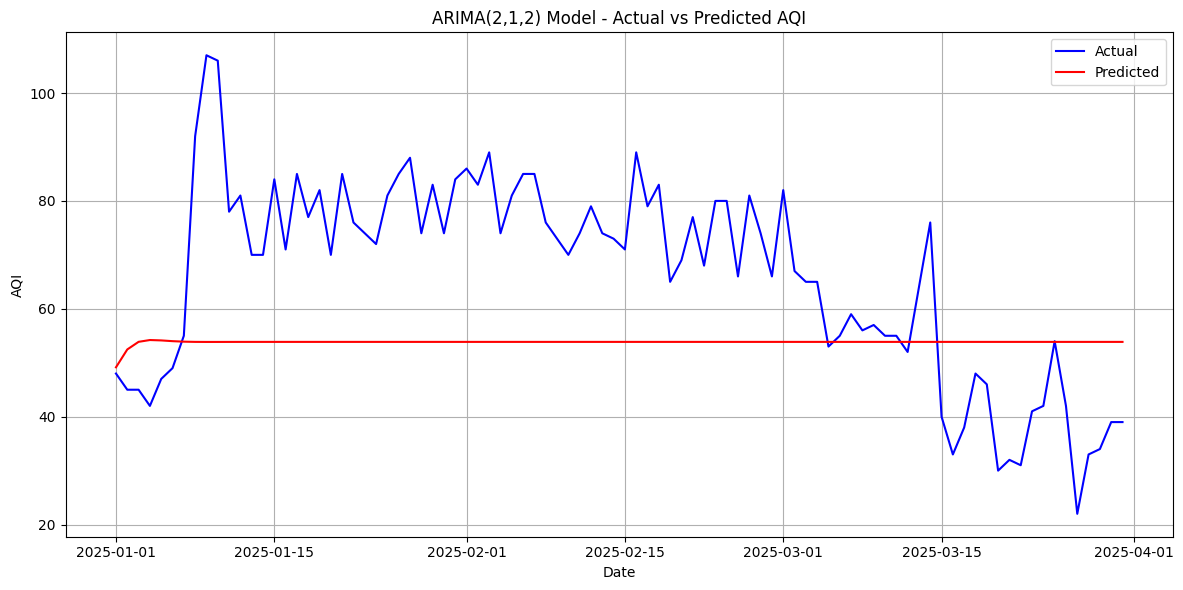


===== SARIMAX MODEL =====
SARIMAX Model Summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6104      0.017     36.435      0.000       0.578       0.643
ma.L1         -0.9446      0.012    -80.324      0.000      -0.968      -0.922
ar.S.L7        0.0303      0.025      1.227      0.220      -0.018       0.079
ma.S.L7       -0.9999      1.066     -0.938      0.348      -3.089       1.089
sigma2       366.5171    389.708      0.940      0.347    -397.297    1130.332

SARIMAX Metrics:
MAE: 18.0194
RMSE: 20.7107
MAPE: 28.9064


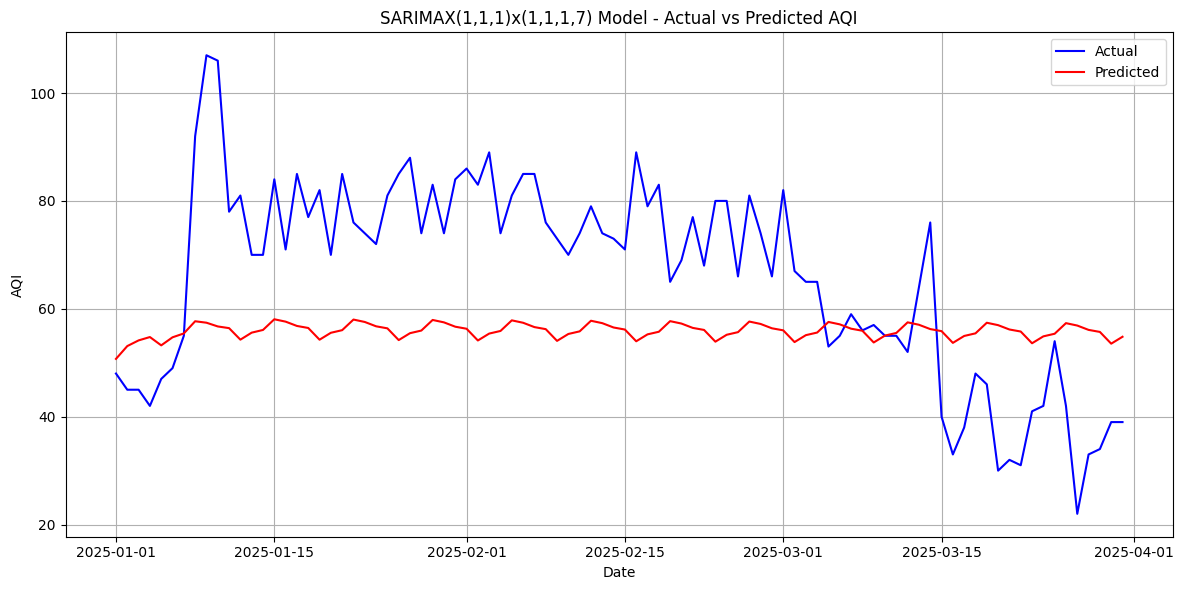


===== PROPHET MODEL =====


DEBUG:cmdstanpy:input tempfile: /tmp/tmp0yfmkaq4/rgt6_30r.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0yfmkaq4/d0z44t50.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=57591', 'data', 'file=/tmp/tmp0yfmkaq4/rgt6_30r.json', 'init=/tmp/tmp0yfmkaq4/d0z44t50.json', 'output', 'file=/tmp/tmp2axguzd1/prophet_modelftx7d2we/prophet_model-20250428145636.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:56:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:56:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



Prophet Metrics:
MAE: 26.5433
RMSE: 29.6840
MAPE: 39.0652


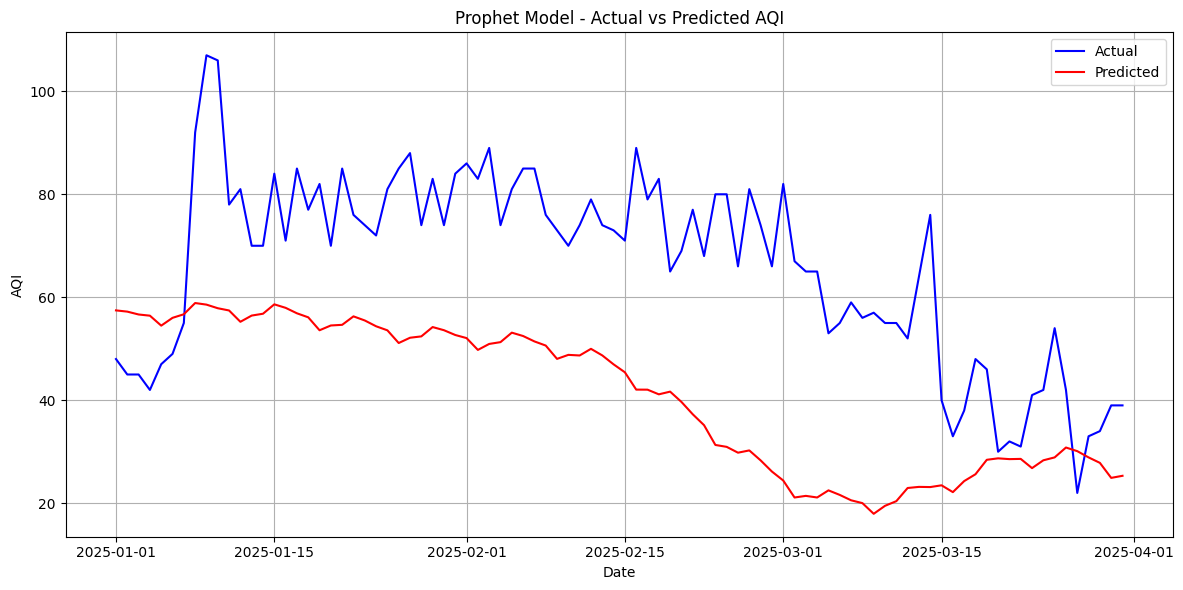

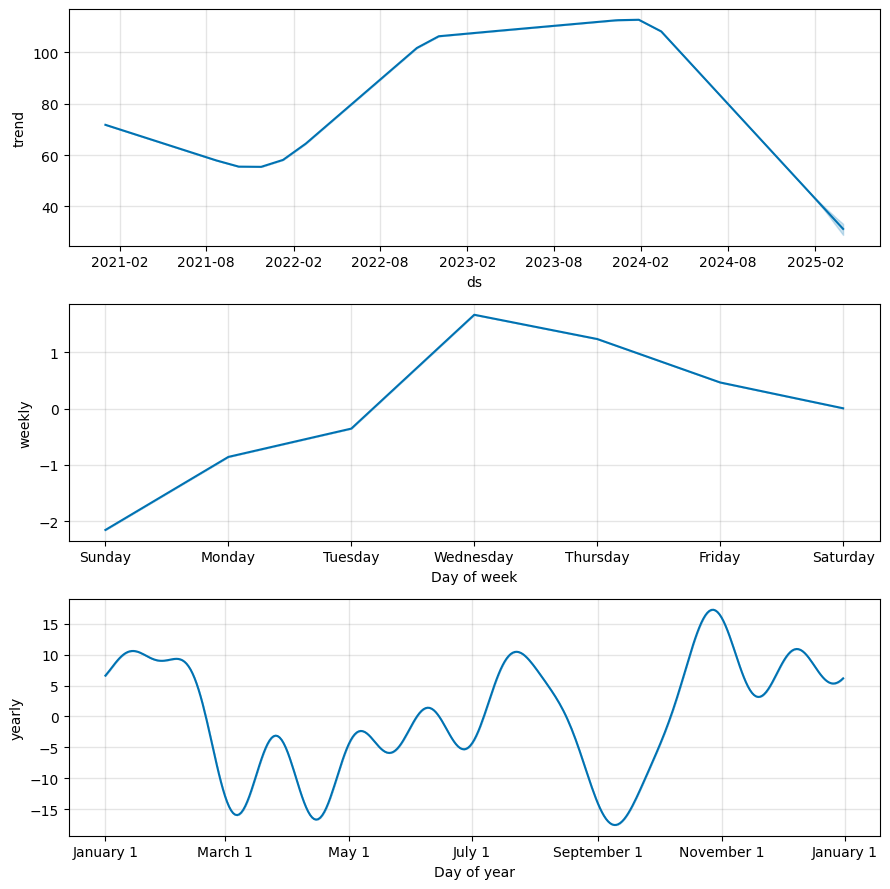


===== MODEL COMPARISON =====
          ARIMA    SARIMAX    Prophet
MAE   19.169252  18.019377  26.543263
RMSE  22.045611  20.710719  29.683988
MAPE  29.849977  28.906448  39.065173


<Figure size 1200x800 with 0 Axes>

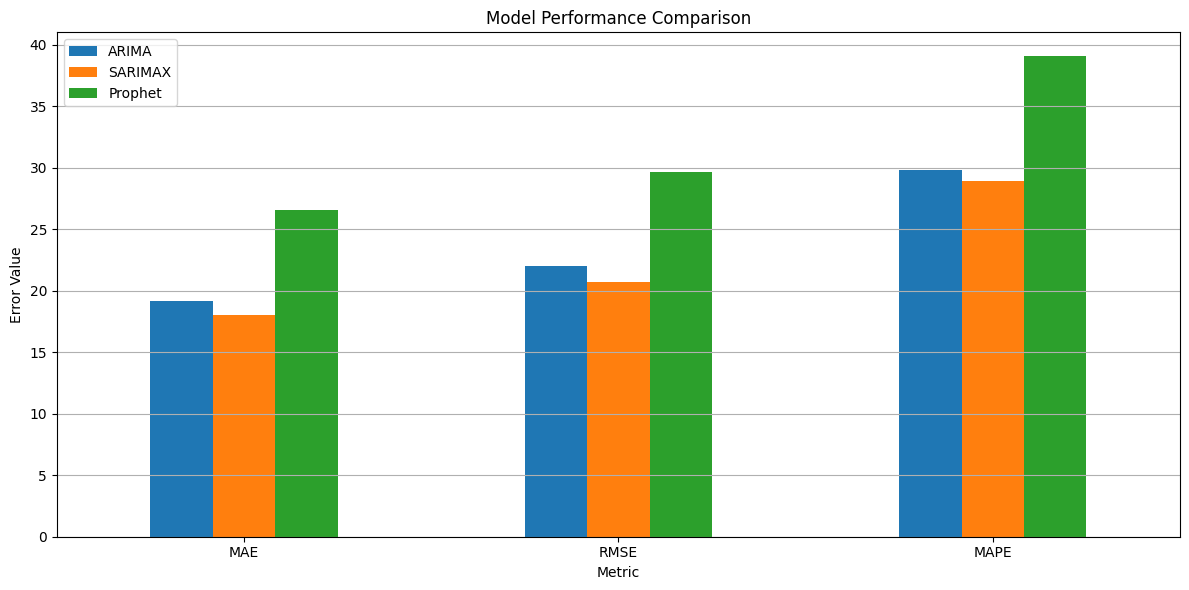

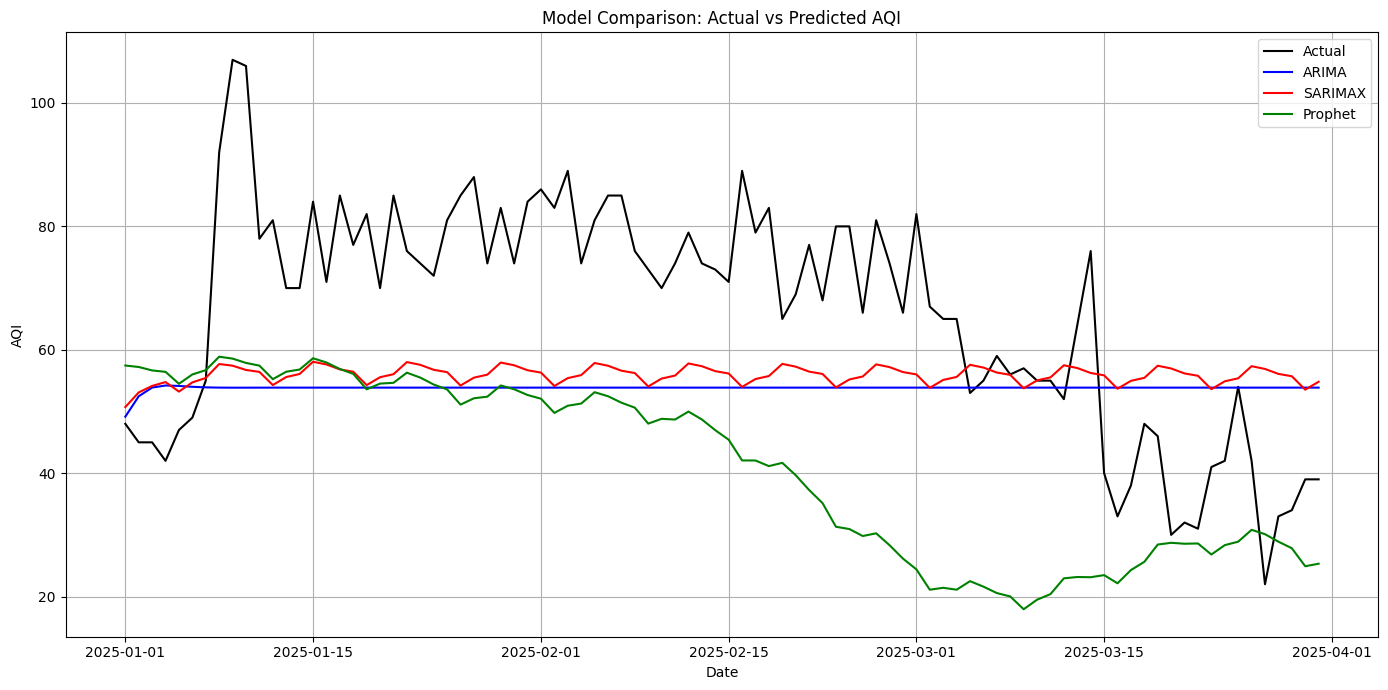


Based on overall metrics, the best performing model is: MAE


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('alandur_daily.csv')

# Convert the date column to datetime format
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index()

# Split the data into training and testing sets (last 90 days for testing)
train_size = len(df) - 90
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Training data from {train.index.min()} to {train.index.max()}")
print(f"Testing data from {test.index.min()} to {test.index.max()}")
print(f"Training set size: {len(train)}")
print(f"Testing set size: {len(test)}")

# Function to calculate metrics
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape
    }

# Function to plot results
def plot_results(df_results, title):
    plt.figure(figsize=(12, 6))
    plt.plot(df_results.index, df_results['Actual'], label='Actual', color='blue')
    plt.plot(df_results.index, df_results['Predicted'], label='Predicted', color='red')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('AQI')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ========== ARIMA MODEL ==========
print("\n===== ARIMA MODEL =====")
# Based on our analysis, we'll use ARIMA(2,1,2)
model_arima = ARIMA(train['AQI'], order=(2, 1, 2))
results_arima = model_arima.fit()
print("ARIMA Model Summary:")
print(results_arima.summary().tables[1])

# Make predictions
pred_arima = results_arima.forecast(steps=len(test))

# Create a DataFrame with actual and predicted values
df_results_arima = pd.DataFrame({
    'Actual': test['AQI'],
    'Predicted': pred_arima
})

# Calculate metrics for ARIMA
arima_metrics = calculate_metrics(test['AQI'], pred_arima)
print("\nARIMA Metrics:")
for metric, value in arima_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot ARIMA results
plot_results(df_results_arima, 'ARIMA(2,1,2) Model - Actual vs Predicted AQI')

# ========== SARIMAX MODEL ==========
print("\n===== SARIMAX MODEL =====")
# Based on our analysis, we'll use SARIMAX(1,1,1)x(1,1,1,7)
model_sarimax = SARIMAX(
    train['AQI'],
    order=(1, 1, 1),             # Non-seasonal components (p,d,q)
    seasonal_order=(1, 1, 1, 7)  # Seasonal components (P,D,Q,s)
)
results_sarimax = model_sarimax.fit(disp=False)
print("SARIMAX Model Summary:")
print(results_sarimax.summary().tables[1])

# Make predictions
pred_sarimax = results_sarimax.forecast(steps=len(test))

# Create a DataFrame with actual and predicted values
df_results_sarimax = pd.DataFrame({
    'Actual': test['AQI'],
    'Predicted': pred_sarimax
})

# Calculate metrics for SARIMAX
sarimax_metrics = calculate_metrics(test['AQI'], pred_sarimax)
print("\nSARIMAX Metrics:")
for metric, value in sarimax_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot SARIMAX results
plot_results(df_results_sarimax, 'SARIMAX(1,1,1)x(1,1,1,7) Model - Actual vs Predicted AQI')

# ========== PROPHET MODEL ==========
print("\n===== PROPHET MODEL =====")
# Prepare data for Prophet (requires 'ds' and 'y' columns)
prophet_train = train.reset_index()
prophet_train = prophet_train.rename(columns={'Datetime': 'ds', 'AQI': 'y'})
prophet_test = test.reset_index()
prophet_test = prophet_test.rename(columns={'Datetime': 'ds', 'AQI': 'y'})

# Initialize and fit the Prophet model
model_prophet = Prophet(
    yearly_seasonality=True,     # Annual pattern
    weekly_seasonality=True,     # Weekly pattern
    daily_seasonality=False,     # No daily pattern (we have daily data)
    changepoint_prior_scale=0.05 # Default value for flexibility in trend changes
)
model_prophet.fit(prophet_train)

# Make predictions
future = model_prophet.make_future_dataframe(periods=len(test), freq='D')
forecast = model_prophet.predict(future)
pred_prophet = forecast.iloc[-len(test):]['yhat'].values

# Create a DataFrame with actual and predicted values
df_results_prophet = pd.DataFrame({
    'Actual': test['AQI'],
    'Predicted': pred_prophet
})
df_results_prophet.index = test.index

# Calculate metrics for Prophet
prophet_metrics = calculate_metrics(test['AQI'], pred_prophet)
print("\nProphet Metrics:")
for metric, value in prophet_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot Prophet results
plot_results(df_results_prophet, 'Prophet Model - Actual vs Predicted AQI')

# Plot Prophet components
model_prophet.plot_components(forecast)
plt.tight_layout()
plt.show()

# ========== MODEL COMPARISON ==========
print("\n===== MODEL COMPARISON =====")
metrics_comparison = pd.DataFrame({
    'ARIMA': [arima_metrics['MAE'], arima_metrics['RMSE'], arima_metrics['MAPE']],
    'SARIMAX': [sarimax_metrics['MAE'], sarimax_metrics['RMSE'], sarimax_metrics['MAPE']],
    'Prophet': [prophet_metrics['MAE'], prophet_metrics['RMSE'], prophet_metrics['MAPE']]
}, index=['MAE', 'RMSE', 'MAPE'])

print(metrics_comparison)

# Create a bar chart for visual comparison
plt.figure(figsize=(12, 8))
metrics_comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Error Value')
plt.xlabel('Metric')
plt.grid(True, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Create combined plot for all models
plt.figure(figsize=(14, 7))
plt.plot(df_results_arima.index, df_results_arima['Actual'], label='Actual', color='black')
plt.plot(df_results_arima.index, df_results_arima['Predicted'], label='ARIMA', color='blue')
plt.plot(df_results_sarimax.index, df_results_sarimax['Predicted'], label='SARIMAX', color='red')
plt.plot(df_results_prophet.index, df_results_prophet['Predicted'], label='Prophet', color='green')
plt.title('Model Comparison: Actual vs Predicted AQI')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Determine best model
best_model = metrics_comparison.idxmin().mode()[0]
print(f"\nBased on overall metrics, the best performing model is: {best_model}")


===== SARIMAX MODEL =====
SARIMAX Model Summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -2.2635      0.012   -194.612      0.000      -2.286      -2.241
ma.L2          1.2521      0.034     37.038      0.000       1.186       1.318
ma.L3          0.1056      0.049      2.165      0.030       0.010       0.201
ma.L4          0.0092      0.062      0.147      0.883      -0.113       0.131
ma.L5          0.0070      0.063      0.110      0.912      -0.117       0.131
ma.L6         -0.1196      0.067     -1.777      0.076      -0.252       0.012
ma.L7         -0.0241      0.067     -0.362      0.717      -0.155       0.106
ma.L8          0.0837      0.061      1.363      0.173      -0.037       0.204
ma.L9         -0.1246      0.064     -1.951      0.051      -0.250       0.001
ma.L10         0.0706      0.069      1.017      0.309      -0.066       0.207
ma

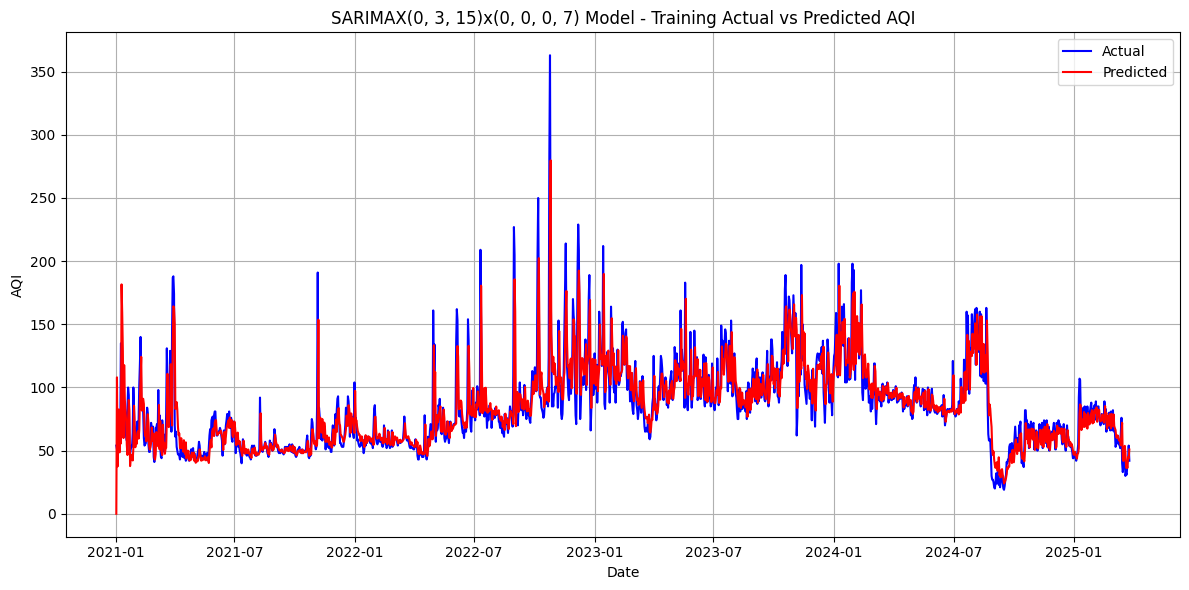

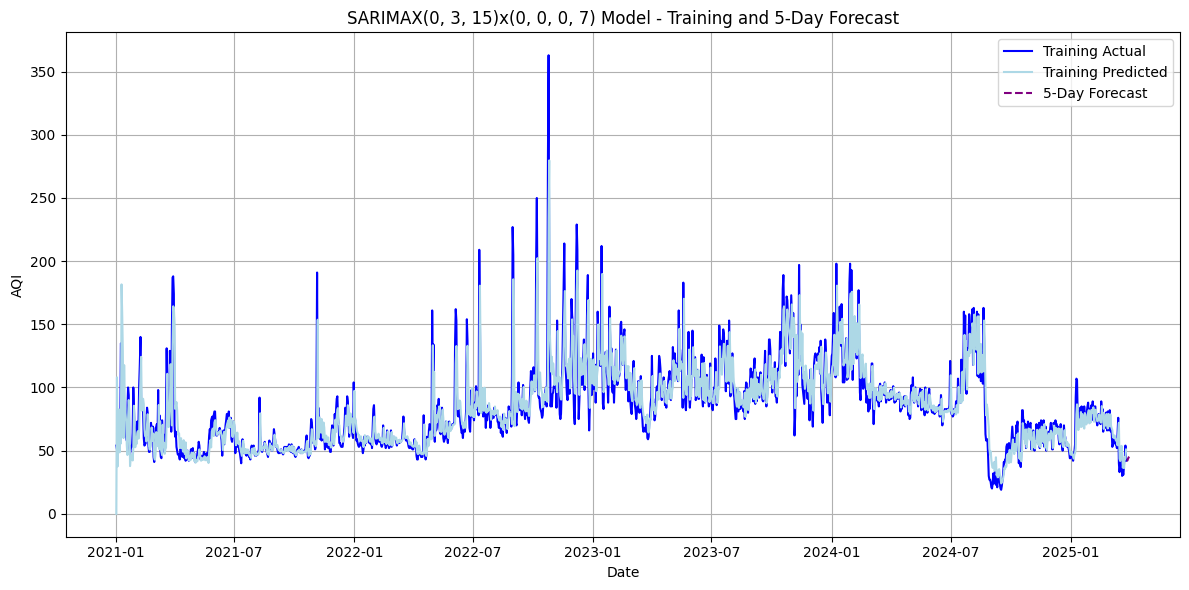

In [26]:
# ========== SARIMAX MODEL ==========
print("\n===== SARIMAX MODEL =====")
# Based on the given parameters, SARIMAX(0,3,15)x(0,0,0,7)
model_sarimax = SARIMAX(
    train['AQI'],
    order=(0, 3, 15),             # Non-seasonal components (p, d, q)
    seasonal_order=(0, 0, 0, 7)   # Seasonal components (P, D, Q, s)
)
results_sarimax = model_sarimax.fit(disp=False)
print("SARIMAX Model Summary:")
print(results_sarimax.summary().tables[1])

# Make predictions for the training set (actual vs predicted on training data)
pred_train_sarimax = results_sarimax.predict(start=train.index[0], end=train.index[-1])

# Create a DataFrame with actual and predicted values for the training set
df_results_train_sarimax = pd.DataFrame({
    'Actual': train['AQI'],
    'Predicted': pred_train_sarimax
})

# Calculate metrics for SARIMAX on the training set
sarimax_train_metrics = calculate_metrics(train['AQI'], pred_train_sarimax)
print("\nSARIMAX Training Set Metrics:")
for metric, value in sarimax_train_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot SARIMAX results for the training set
plot_results(df_results_train_sarimax, 'SARIMAX(0, 3, 15)x(0, 0, 0, 7) Model - Training Actual vs Predicted AQI')

# Forecast for the next 5 days (or the next N days)
pred_forecast_5_days = results_sarimax.forecast(steps=5)

# Create DataFrame for the 5-day forecast
forecast_dates = pd.date_range(start=train.index[-1] + pd.Timedelta(days=1), periods=5, freq='D')
df_results_forecast_5_days = pd.DataFrame({
    'Predicted': pred_forecast_5_days
}, index=forecast_dates)

# Plot the 5-day forecast
plt.figure(figsize=(12, 6))
plt.plot(df_results_train_sarimax.index, df_results_train_sarimax['Actual'], label='Training Actual', color='blue')
plt.plot(df_results_train_sarimax.index, df_results_train_sarimax['Predicted'], label='Training Predicted', color='lightblue')
plt.plot(df_results_forecast_5_days.index, df_results_forecast_5_days['Predicted'], label='5-Day Forecast', color='purple', linestyle='--')
plt.title('SARIMAX(0, 3, 15)x(0, 0, 0, 7) Model - Training and 5-Day Forecast')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
